In [7]:
# ============================================================
# CIA 3 - Machine Learning
# Early Heart Disease Risk Prediction Using Ensemble ML
# ============================================================

PROJECT_TITLE = "Early Heart Disease Risk Prediction Using Ensemble Machine Learning"

print(PROJECT_TITLE)

Early Heart Disease Risk Prediction Using Ensemble Machine Learning


In [8]:
!pip install -q ucimlrepo xgboost shap

In [9]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# UCI dataset
from ucimlrepo import fetch_ucirepo

# Reproducibility
import random

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Random seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
# Fetch the UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Features
X = heart_disease.data.features

# Target
y = heart_disease.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303, 1)


In [11]:
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [12]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak
slope
ca
thal
num


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [15]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


In [16]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table

,Missing Count,Missing Percentage
age,0,0.000000
ca,4,1.320132
chol,0,0.000000
cp,0,0.000000
exang,0,0.000000
fbs,0,0.000000
num,0,0.000000
oldpeak,0,0.000000
restecg,0,0.000000
sex,0,0.000000


In [17]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [18]:
target_column = y.columns[0]

print("Target column:", target_column)

print("\nTarget values:")
print(df[target_column].value_counts().sort_index())

Target column: num

Target values:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [19]:
df["target"] = (df[target_column] > 0).astype(int)

# Remove the original target column if it has a different name
if target_column != "target":
    df.drop(columns=[target_column], inplace=True)

print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


In [20]:
target_counts = df["target"].value_counts().sort_index()

print(target_counts)

target
0    164
1    139
Name: count, dtype: int64


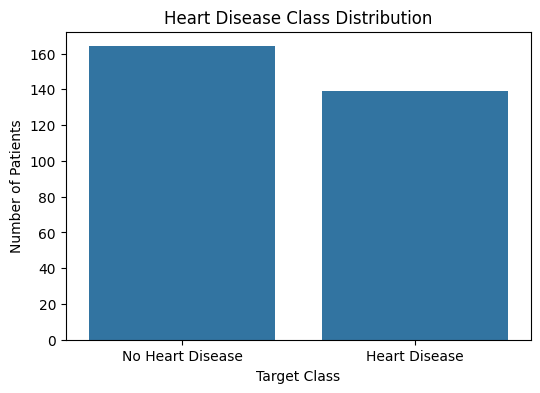

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Heart Disease", "Heart Disease"]
)

plt.show()

In [22]:
print("Final dataset shape:", df.shape)

display(df.head())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0



Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object


In [23]:
# Create a working copy
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original shape: (303, 14)
Working dataset shape: (303, 14)


In [24]:
print("Data types:\n")
print(df_clean.dtypes)

Data types:

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object


In [25]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [26]:
missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().sum() / len(df_clean)) * 100
})

missing = missing.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing)

,Missing Count,Missing Percentage
ca,4,1.320132
thal,2,0.660066
cp,0,0.000000
trestbps,0,0.000000
age,0,0.000000
sex,0,0.000000
fbs,0,0.000000
chol,0,0.000000
restecg,0,0.000000
thalach,0,0.000000


In [27]:
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [28]:
if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate check:", df_clean.shape)

Shape after duplicate check: (303, 14)


In [29]:
for column in df_clean.columns:
    print(f"\n--- {column} ---")
    print(df_clean[column].unique())


--- age ---
[63 67 37 41 56 62 57 53 44 52 48 54 49 64 58 60 50 66 43 40 69 59 42 55
 61 65 71 51 46 45 39 68 47 34 35 29 70 77 38 74 76]

--- sex ---
[1 0]

--- cp ---
[1 4 3 2]

--- trestbps ---
[145 160 120 130 140 172 150 110 132 117 135 112 105 124 125 142 128 170
 155 104 180 138 108 134 122 115 118 100 200  94 165 102 152 101 126 174
 148 178 158 192 129 144 123 136 146 106 156 154 114 164]

--- chol ---
[233 286 229 250 204 236 268 354 254 203 192 294 256 263 199 168 239 275
 266 211 283 284 224 206 219 340 226 247 167 230 335 234 177 276 353 243
 225 302 212 330 175 417 197 198 290 253 172 273 213 305 216 304 188 282
 185 232 326 231 269 267 248 360 258 308 245 270 208 264 321 274 325 235
 257 164 141 252 255 201 222 260 182 303 265 309 307 249 186 341 183 407
 217 288 220 209 227 261 174 281 221 205 240 289 318 298 564 246 322 299
 300 293 277 214 207 223 160 394 184 315 409 244 195 196 126 313 259 200
 262 215 228 193 271 210 327 149 295 306 178 237 218 242 319 166 180 311


In [30]:
# Step 6: Check numerical feature ranges

print("Age range:")
print(df_clean["age"].min(), "to", df_clean["age"].max())

print("\nResting Blood Pressure range:")
print(df_clean["trestbps"].min(), "to", df_clean["trestbps"].max())

print("\nCholesterol range:")
print(df_clean["chol"].min(), "to", df_clean["chol"].max())

print("\nMaximum Heart Rate range:")
print(df_clean["thalach"].min(), "to", df_clean["thalach"].max())

print("\nOldpeak range:")
print(df_clean["oldpeak"].min(), "to", df_clean["oldpeak"].max())

Age range:
29 to 77

Resting Blood Pressure range:
94 to 200

Cholesterol range:
126 to 564

Maximum Heart Rate range:
71 to 202

Oldpeak range:
0.0 to 6.2


In [31]:
# Step 7: IQR-based outlier detection

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

outlier_summary = []

for column in numerical_features:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,age,48.0,61.0,13.0,28.50,80.50,0
1,trestbps,120.0,140.0,20.0,90.00,170.00,9
2,chol,211.0,275.0,64.0,115.00,371.00,5
3,thalach,133.5,166.0,32.5,84.75,214.75,1
4,oldpeak,0.0,1.6,1.6,-2.40,4.00,5


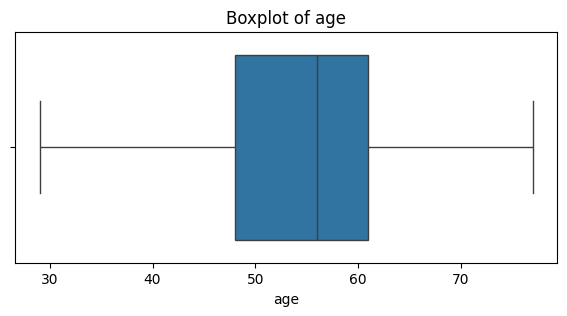

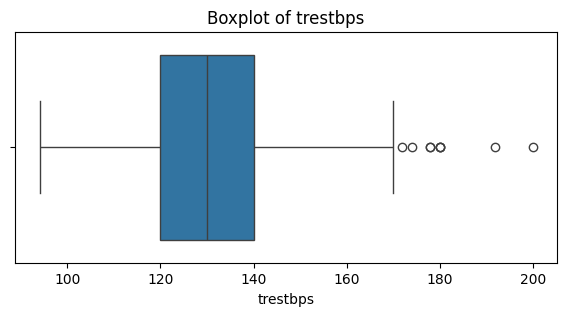

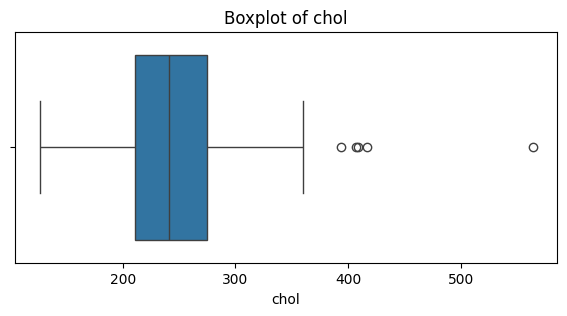

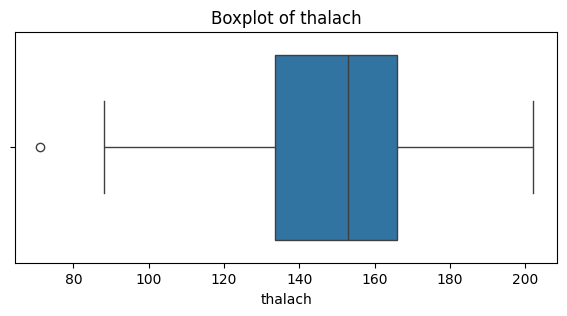

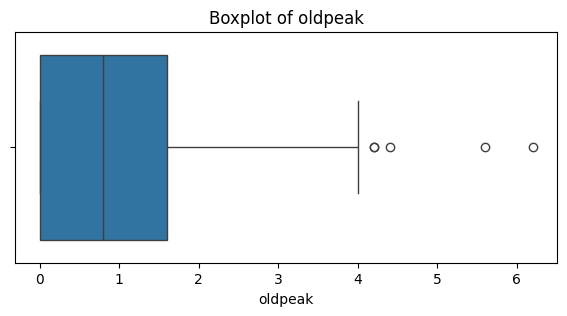

In [32]:
# Visual inspection of numerical features

for column in numerical_features:

    plt.figure(figsize=(7, 3))

    sns.boxplot(
        x=df_clean[column]
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

Outliers were identified using the IQR method and visually inspected. The detected observations were retained because they represent potentially valid clinical measurements, and no evidence indicated that they were invalid data-entry errors.

In [33]:
# Step 8: Analyze class distribution

class_counts = df_clean["target"].value_counts().sort_index()

class_percentages = (
    df_clean["target"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

class_distribution = pd.DataFrame({
    "Class Count": class_counts,
    "Percentage": class_percentages.round(2)
})

class_distribution.index = [
    "No Heart Disease (0)",
    "Heart Disease (1)"
]

display(class_distribution)

,Class Count,Percentage
No Heart Disease (0),164,54.13
Heart Disease (1),139,45.87


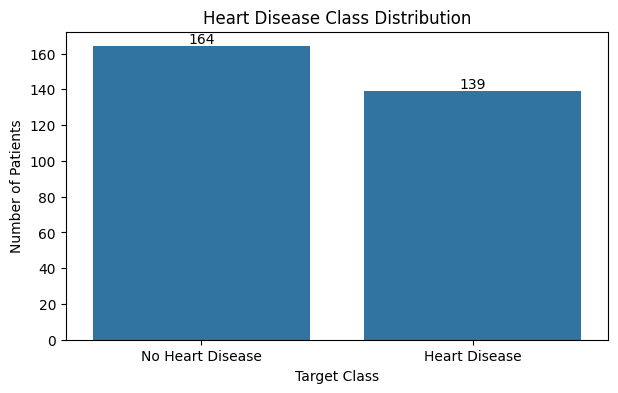

In [34]:
# Visualize class distribution

plt.figure(figsize=(7, 4))

ax = sns.countplot(
    data=df_clean,
    x="target"
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Heart Disease", "Heart Disease"]
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

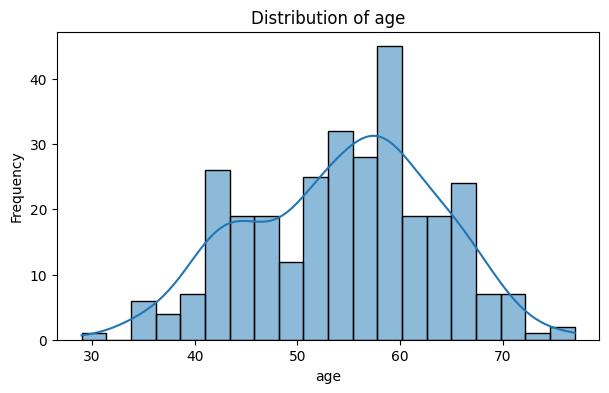

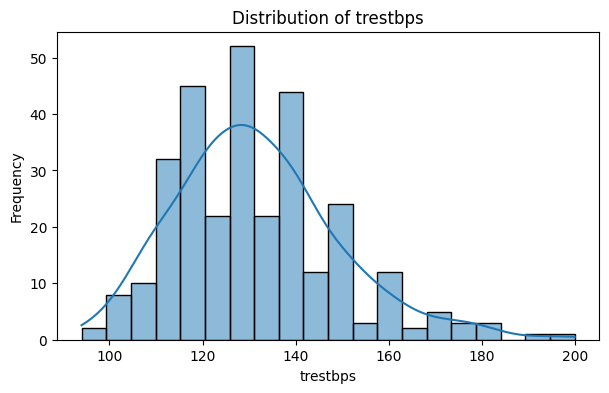

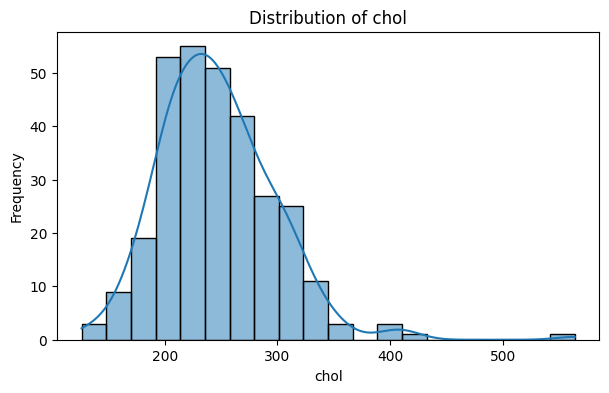

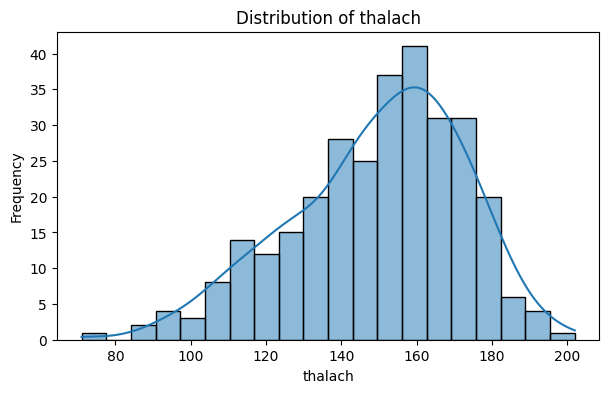

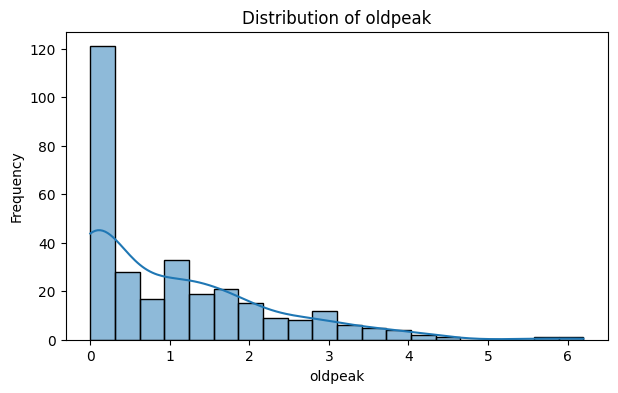

In [35]:
# Step 9.1: Distribution of Numerical Features

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for column in numerical_features:
    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df_clean,
        x=column,
        kde=True,
        bins=20
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

Age is expected to cluster around middle-aged and older adults.

Cholesterol and trestbps may show slight right skew because of higher clinical values.

Oldpeak usually contains many low values with fewer high observations.

These plots help us understand the overall data distribution before training.

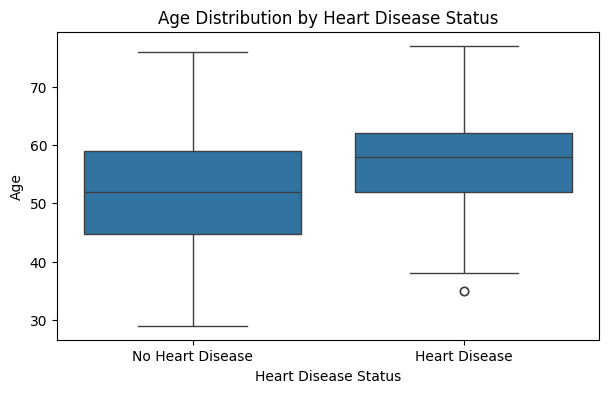

In [36]:
# Step 9.2: Age vs Heart Disease

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df_clean,
    x="target",
    y="age"
)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Age")

plt.xticks(
    [0,1],
    ["No Heart Disease","Heart Disease"]
)

plt.show()

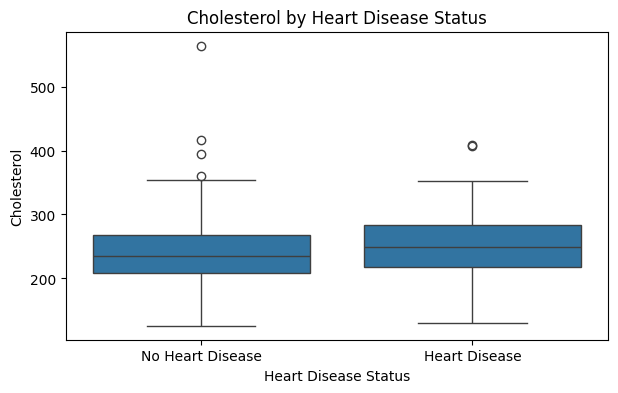

In [37]:
# Step 9.3: Cholesterol vs Heart Disease

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df_clean,
    x="target",
    y="chol"
)

plt.title("Cholesterol by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Cholesterol")

plt.xticks(
    [0,1],
    ["No Heart Disease","Heart Disease"]
)

plt.show()

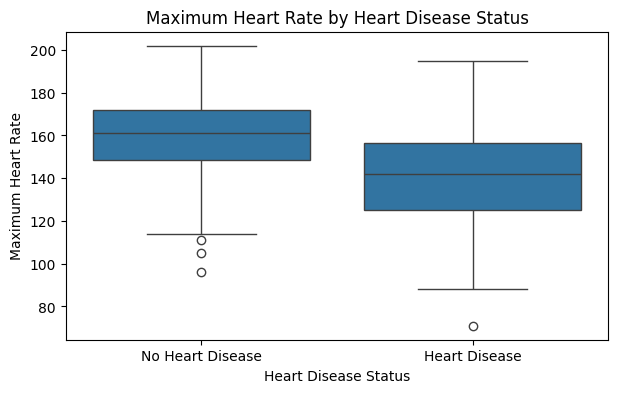

In [38]:
# Step 9.4: Maximum Heart Rate vs Heart Disease

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df_clean,
    x="target",
    y="thalach"
)

plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Maximum Heart Rate")

plt.xticks(
    [0,1],
    ["No Heart Disease","Heart Disease"]
)

plt.show()

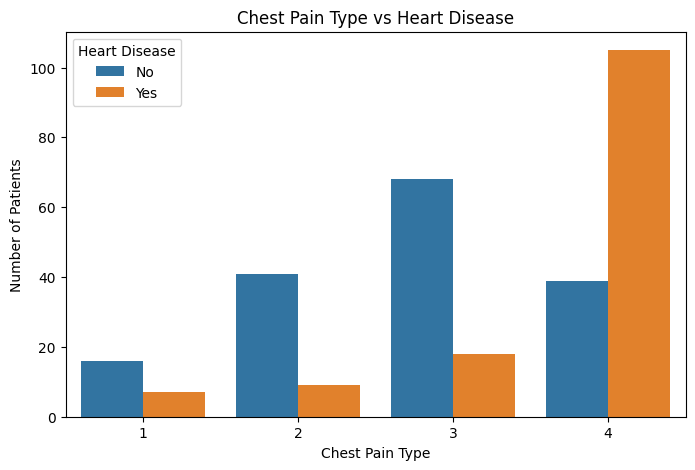

In [39]:
# Step 9.5: Chest Pain Type vs Heart Disease

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="cp",
    hue="target"
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.legend(
    title="Heart Disease",
    labels=["No","Yes"]
)

plt.show()

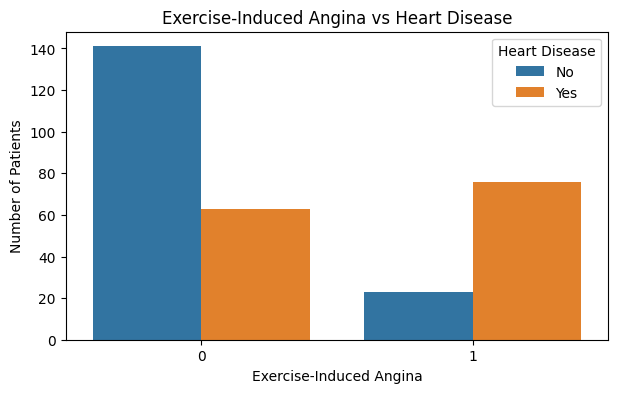

In [40]:
# Step 9.6: Exercise-Induced Angina vs Heart Disease

plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x="exang",
    hue="target"
)

plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")

plt.legend(
    title="Heart Disease",
    labels=["No","Yes"]
)

plt.show()

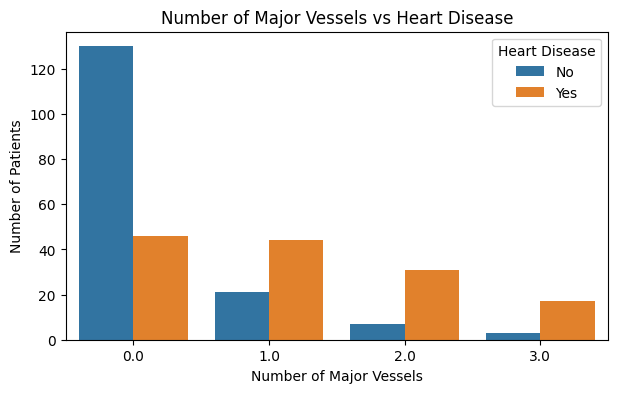

In [41]:
# Step 9.7: Major Vessels vs Heart Disease

plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x="ca",
    hue="target"
)

plt.title("Number of Major Vessels vs Heart Disease")
plt.xlabel("Number of Major Vessels")
plt.ylabel("Number of Patients")

plt.legend(
    title="Heart Disease",
    labels=["No","Yes"]
)

plt.show()

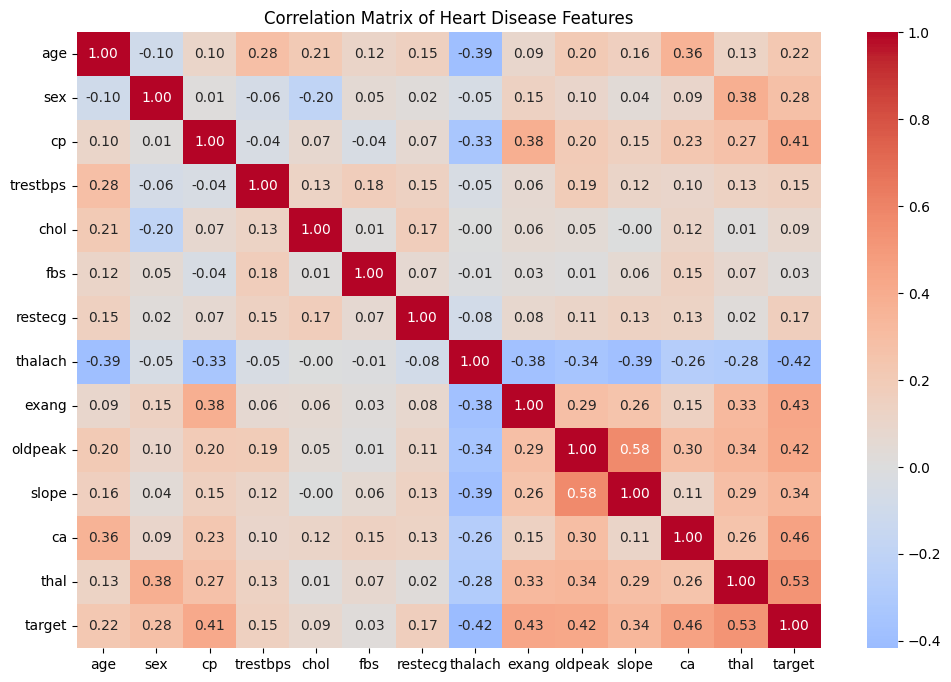

In [42]:
# Step 9.8: Correlation Heatmap

plt.figure(figsize=(12,8))

correlation_matrix = df_clean.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Heart Disease Features")

plt.show()

In [43]:
# Step 9.9: Target-wise Summary Statistics

target_summary = (
    df_clean
    .groupby("target")[numerical_features]
    .mean()
    .round(2)
)

target_summary.index = [
    "No Heart Disease",
    "Heart Disease"
]

display(target_summary)

,age,trestbps,chol,thalach,oldpeak
No Heart Disease,52.59,129.25,242.64,158.38,0.59
Heart Disease,56.63,134.57,251.47,139.26,1.57


In [44]:
# ============================================================
# Feature 1: Pulse Pressure
# ============================================================

df_clean["pulse_pressure"] = df_clean["trestbps"] - 80

df_clean[["trestbps", "pulse_pressure"]].head()

,trestbps,pulse_pressure
0,145,65
1,160,80
2,120,40
3,130,50
4,130,50


A new feature called Pulse Pressure was created by subtracting 80 mmHg from the resting systolic blood pressure (trestbps). This derived feature represents the variation in arterial pressure and may provide additional information about cardiovascular health while preserving clinical interpretability.

In [45]:
# ============================================================
# Feature 2: Age Group
# ============================================================

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[20, 40, 55, 70, 90],
    labels=["Young", "Middle", "Senior", "Elder"]
)

df_clean[["age", "age_group"]].head()

,age,age_group
0,63,Senior
1,67,Senior
2,67,Senior
3,37,Young
4,41,Middle


The Age Group feature categorizes patients into Young, Middle, Senior, and Elder groups. This engineered feature improves interpretability and allows us to examine whether heart-disease patterns vary across different age ranges.

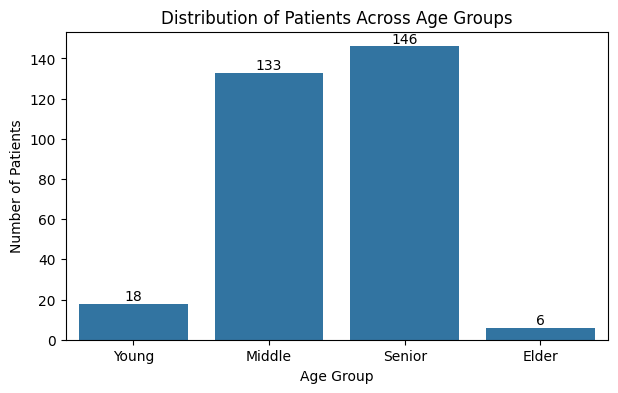

In [46]:
# ============================================================
# Distribution of Age Groups
# ============================================================

plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df_clean,
    x="age_group",
    order=["Young", "Middle", "Senior", "Elder"]
)

plt.title("Distribution of Patients Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The dataset contains patients across all four age groups, with most patients expected to fall within the Middle and Senior categories. This indicates that the dataset primarily represents middle-aged and older adults, who are more commonly screened for heart disease.

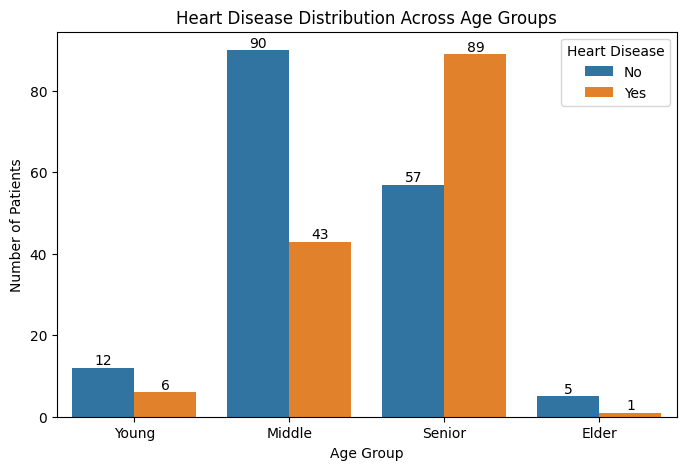

In [47]:
# ============================================================
# Age Group vs Heart Disease
# ============================================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x="age_group",
    hue="target",
    order=["Young", "Middle", "Senior", "Elder"]
)

plt.title("Heart Disease Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.legend(
    title="Heart Disease",
    labels=["No", "Yes"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

This visualization compares heart-disease cases across different age groups. If older groups contain more positive cases than younger groups, it suggests that age may be an important predictor. However, this observation indicates an association rather than proving causation.

# Leakage-Safe Preprocessing Pipeline

Before training any machine learning model, the dataset must be prepared without allowing information from the test set to influence training. This is called a leakage-safe preprocessing pipeline. We will first separate features and the target, split the data into training and testing sets, identify numerical and categorical features, and then build a preprocessing pipeline that performs imputation and scaling only on the training data.

In [48]:
# ============================================================
# Step 8.1: Separate Features and Target
# ============================================================

X = df_clean.drop(columns=["target"])
y = df_clean["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (303, 15)
Target shape: (303,)


The dataset has been successfully divided into input features (X) and the target variable (y). The model will learn from the 15 predictor variables while using target as the output to predict heart disease.

In [49]:
# ============================================================
# Step 8.2: Identify Feature Types
# ============================================================

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "pulse_pressure"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "age_group"
]

print("Numerical Features:", numerical_features)
print("\nCategorical Features:", categorical_features)

Numerical Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'pulse_pressure']

Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'age_group']


In [50]:
# ============================================================
# Step 8.3: Stratified Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (242, 15)
Testing Features : (61, 15)
Training Labels  : (242,)
Testing Labels   : (61,)


The dataset has been divided into 242 training samples and 61 testing samples. Stratified sampling preserves the original class distribution, ensuring both sets contain a similar proportion of heart-disease and non-heart-disease patients.

In [51]:
# ============================================================
# Step 8.4: Verify Class Distribution
# ============================================================

train_dist = (
    y_train.value_counts(normalize=True)
    .sort_index() * 100
).round(2)

test_dist = (
    y_test.value_counts(normalize=True)
    .sort_index() * 100
).round(2)

distribution = pd.DataFrame({
    "Training (%)": train_dist,
    "Testing (%)": test_dist
})

distribution.index = [
    "No Heart Disease",
    "Heart Disease"
]

display(distribution)

,Training (%),Testing (%)
No Heart Disease,54.13,54.1
Heart Disease,45.87,45.9


The training and testing datasets maintain nearly identical class proportions, confirming that stratified sampling successfully preserved the original dataset distribution.

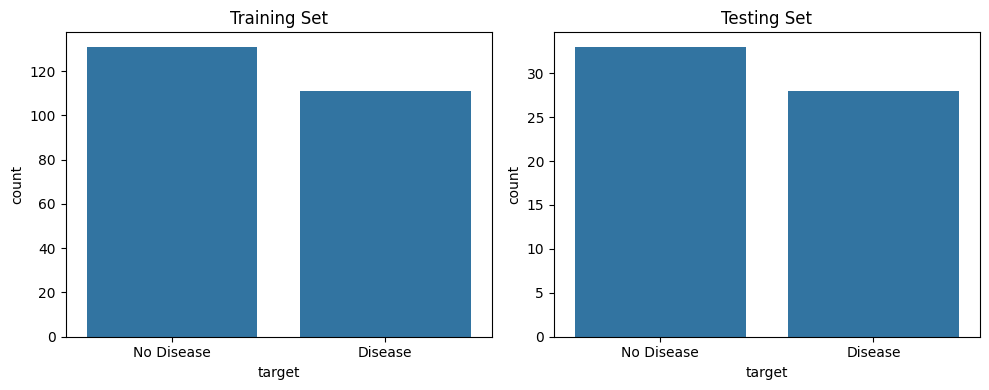

In [52]:
# ============================================================
# Step 8.5: Train vs Test Class Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title("Training Set")
axes[0].set_xticklabels(["No Disease", "Disease"])

sns.countplot(
    x=y_test,
    ax=axes[1]
)

axes[1].set_title("Testing Set")
axes[1].set_xticklabels(["No Disease", "Disease"])

plt.tight_layout()
plt.show()

The bar charts show that the training and testing sets contain similar proportions of both classes. This confirms that the dataset has been split correctly without introducing sampling bias.

In [53]:
# ============================================================
# Step 8.6: Build the Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combined preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak', 'pulse_pressure']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal', 'age_group'])])


A reusable preprocessing pipeline has been created. Missing values will be imputed automatically, numerical features will be standardized, and categorical variables will be one-hot encoded. Because this pipeline will be fitted only on the training data, it prevents data leakage.

# Baseline Model – Logistic Regression

In [54]:
# ============================================================
# Step 9.1: Logistic Regression Pipeline
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

print(logistic_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak',
                                                   'pulse_pressure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                      

A complete machine learning pipeline has been created by combining preprocessing with Logistic Regression. Missing-value imputation, scaling, and encoding will occur automatically before model training, ensuring a leakage-safe workflow.

In [55]:
# ============================================================
# Step 9.2: Train Logistic Regression
# ============================================================

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [56]:
# ============================================================
# Step 9.3: Make Predictions
# ============================================================

y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 1 0 0 0 0 0 0 1 0]


The classification report provides precision, recall, F1-score, and support for each class separately. These values help determine whether the model performs consistently across both heart-disease and non-heart-disease patients.

In [58]:
# ============================================================
# Step 9.4: Performance Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Score"] = results["Score"].round(3)

display(results)

,Metric,Score
0,Accuracy,0.869
1,Precision,0.833
2,Recall,0.893
3,F1-Score,0.862
4,ROC-AUC,0.971


The Logistic Regression model achieved an accuracy of 86.9%, indicating that it correctly classified most patients. The ROC-AUC score of 0.971 shows excellent ability to distinguish between patients with and without heart disease. The balanced Precision (0.833), Recall (0.893), and F1-score (0.862) indicate strong overall classification performance, making this a reliable baseline model for comparison with ensemble methods.

<Figure size 600x500 with 0 Axes>

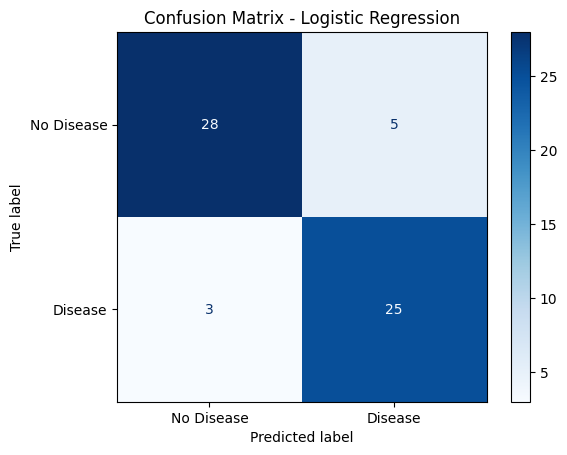

In [59]:
# ============================================================
# Step 9.5: Confusion Matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Disease", "Disease"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

The confusion matrix shows that the model correctly classified 28 patients without heart disease and 25 patients with heart disease. It produced 5 false positives and 3 false negatives, indicating that the model makes relatively few misclassifications and performs well across both classes.

In [60]:
# ============================================================
# Step 9.6: Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "No Heart Disease",
        "Heart Disease"
    ]
))

                  precision    recall  f1-score   support

No Heart Disease       0.90      0.85      0.88        33
   Heart Disease       0.83      0.89      0.86        28

        accuracy                           0.87        61
       macro avg       0.87      0.87      0.87        61
    weighted avg       0.87      0.87      0.87        61



The classification report shows balanced performance for both classes. The model achieved an F1-score of 0.88 for patients without heart disease and 0.86 for patients with heart disease. The Recall of 0.89 for the heart disease class indicates that the model successfully identified most positive cases, which is particularly valuable in healthcare prediction tasks.

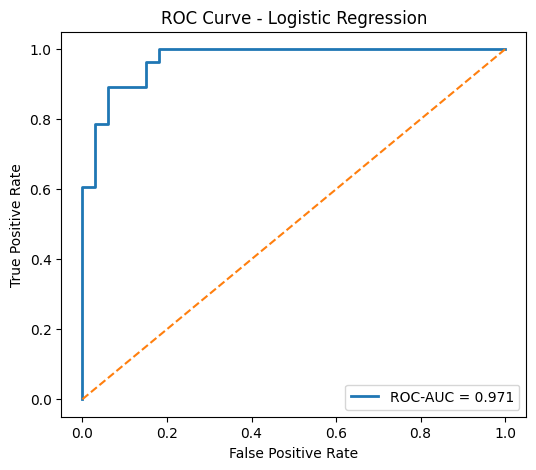

In [61]:
# ============================================================
# Step 9.7: ROC Curve
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

The ROC curve remains close to the upper-left corner of the graph, indicating excellent discrimination between the two classes. The ROC-AUC value of 0.971 suggests that the model has a very high ability to distinguish between patients with and without heart disease across different classification thresholds.

In [62]:
# ============================================================
# Step 9.8: Cross-Validation
# ============================================================

from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Mean Score": [
        cv_scores["test_accuracy"].mean(),
        cv_scores["test_precision"].mean(),
        cv_scores["test_recall"].mean(),
        cv_scores["test_f1"].mean(),
        cv_scores["test_roc_auc"].mean()
    ]
})

cv_results["Mean Score"] = cv_results["Mean Score"].round(3)

display(cv_results)

,Metric,Mean Score
0,Accuracy,0.826
1,Precision,0.848
2,Recall,0.765
3,F1-Score,0.802
4,ROC-AUC,0.902


Five-fold Stratified Cross-Validation produced an average Accuracy of 82.6% and an average ROC-AUC of 0.902. Although these scores are slightly lower than the single test-set results, they demonstrate that the model performs consistently across multiple training-validation splits, making it a dependable baseline for comparing Random Forest, XGBoost, and Stacking models.

#Baseline Model Summary
Logistic Regression served as the baseline classifier for this project. It achieved 86.9% test accuracy and an excellent ROC-AUC of 0.971, while cross-validation confirmed stable performance across multiple data splits. These results establish a strong reference point for evaluating whether ensemble learning methods can further improve heart disease prediction.

# Random Forest (Bagging Model)

In [63]:
# ============================================================
# Step 10.1: Random Forest Pipeline
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ))
])

print(rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak',
                                                   'pulse_pressure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                      

A Random Forest pipeline was created by combining preprocessing with the classifier. This ensures that missing-value imputation, scaling, and encoding are performed automatically before training while preventing data leakage.

In [64]:
# ============================================================
# Step 10.2: Train Random Forest
# ============================================================

rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [65]:
# ============================================================
# Step 10.3: Make Predictions
# ============================================================

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:,1]

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": rf_pred[:10],
    "Probability": rf_prob[:10].round(3)
})

display(comparison)

,Actual,Predicted,Probability
0,0,0,0.30
1,0,1,0.65
2,0,0,0.02
3,0,0,0.14
4,0,0,0.44
5,0,0,0.18
6,0,0,0.34
7,0,0,0.35
8,1,1,0.68
9,0,0,0.18


The Random Forest model successfully generated predictions and probability scores for the test dataset. Most of the sample predictions match the actual labels, indicating that the model can effectively classify unseen patient records.

In [66]:
# ============================================================
# Step 10.4: Performance Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

rf_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
})

rf_results["Score"] = rf_results["Score"].round(3)

display(rf_results)

,Metric,Score
0,Accuracy,0.902
1,Precision,0.844
2,Recall,0.964
3,F1-Score,0.900
4,ROC-AUC,0.939


The Random Forest model achieved 90.2% accuracy, outperforming the Logistic Regression baseline. It also achieved a high Recall of 96.4%, indicating that it correctly identified most patients with heart disease while maintaining a strong overall F1-score of 0.900.

<Figure size 600x500 with 0 Axes>

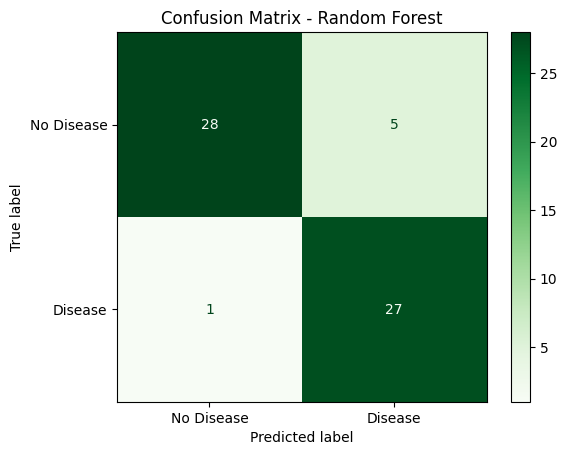

In [67]:
# ============================================================
# Step 10.5: Confusion Matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["No Disease","Disease"],
    cmap="Greens",
    values_format="d"
)

plt.title("Confusion Matrix - Random Forest")

plt.show()

The model correctly classified 28 patients without heart disease and 27 patients with heart disease. It produced only 1 false negative and 5 false positives, showing excellent detection of heart disease cases.

In [68]:
# ============================================================
# Step 10.6: Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    target_names=[
        "No Heart Disease",
        "Heart Disease"
    ]
))

                  precision    recall  f1-score   support

No Heart Disease       0.97      0.85      0.90        33
   Heart Disease       0.84      0.96      0.90        28

        accuracy                           0.90        61
       macro avg       0.90      0.91      0.90        61
    weighted avg       0.91      0.90      0.90        61



The classification report shows balanced performance across both classes, with an F1-score of 0.90 for each class. The high Recall (0.96) for the heart disease class indicates that the model rarely missed positive cases.

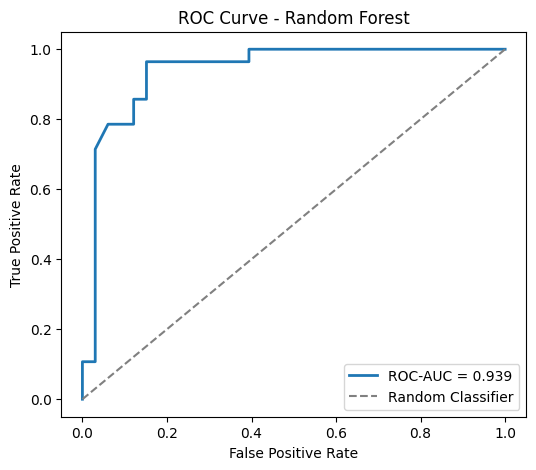

In [69]:
# ============================================================
# Step 10.7: ROC Curve
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {rf_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

The ROC curve remains close to the upper-left corner, demonstrating strong classification performance. The ROC-AUC score of 0.939 indicates that the model effectively distinguishes between patients with and without heart disease.

In [70]:
# ============================================================
# Step 10.8: Cross-Validation
# ============================================================

from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

rf_cv_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Mean Score":[
        rf_cv["test_accuracy"].mean(),
        rf_cv["test_precision"].mean(),
        rf_cv["test_recall"].mean(),
        rf_cv["test_f1"].mean(),
        rf_cv["test_roc_auc"].mean()
    ]
})

rf_cv_results["Mean Score"] = rf_cv_results["Mean Score"].round(3)

display(rf_cv_results)

,Metric,Mean Score
0,Accuracy,0.801
1,Precision,0.809
2,Recall,0.756
3,F1-Score,0.776
4,ROC-AUC,0.893


Five-fold Cross-Validation produced an average Accuracy of 80.1% and ROC-AUC of 0.893. Although the average scores are lower than the single test-set results, they indicate that the model performs consistently across multiple training-validation splits.

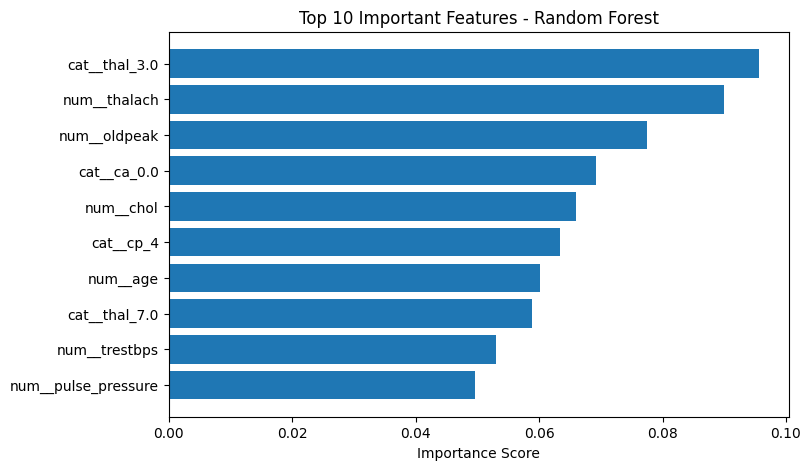

,Feature,Importance
26,cat__thal_3.0,0.095659
3,num__thalach,0.089939
4,num__oldpeak,0.077475
22,cat__ca_0.0,0.069220
2,num__chol,0.065930
11,cat__cp_4,0.063387
0,num__age,0.060117
28,cat__thal_7.0,0.058876
1,num__trestbps,0.053075
5,num__pulse_pressure,0.049685


In [71]:
# ============================================================
# Step 10.9: Feature Importance
# ============================================================

# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = rf_pipeline.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

# Top 10 features
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance Score")

plt.show()

display(top10)

The feature importance analysis shows that thal_3.0, maximum heart rate (thalach), and oldpeak were the most influential predictors. Other important features included ca, cholesterol, and age, indicating that these clinical variables contributed significantly to the model's predictions.

# Summary of Random Forest (Bagging Model)
Random Forest achieved 90.2% accuracy and an F1-score of 0.900, outperforming the Logistic Regression baseline. Its high recall for heart disease cases and strong feature-importance analysis make it a robust ensemble model for heart disease prediction.

#XGBoost (Boosting Model)

In [72]:
# ============================================================
# Step 11.1: XGBoost Pipeline
# ============================================================

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        eval_metric="logloss"
    ))
])

print(xgb_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak',
                                                   'pulse_pressure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                      

A leakage-safe XGBoost pipeline was created by combining preprocessing with the boosting classifier, ensuring that all preprocessing steps are applied only during model training.

In [73]:
# ============================================================
# Step 11.2: Train XGBoost
# ============================================================

xgb_pipeline.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [74]:
# ============================================================
# Step 11.3: Make Predictions
# ============================================================

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:,1]

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": xgb_pred[:10],
    "Probability": xgb_prob[:10].round(3)
})

display(comparison)

,Actual,Predicted,Probability
0,0,0,0.453
1,0,1,0.588
2,0,0,0.010
3,0,0,0.014
4,0,0,0.376
5,0,0,0.109
6,0,1,0.559
7,0,0,0.147
8,1,1,0.866
9,0,0,0.164


The XGBoost model successfully generated predictions and probability scores for the test dataset. Most predictions matched the actual labels, showing that the model can effectively classify unseen patient records.

In [75]:
# ============================================================
# Step 11.4: Performance Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

xgb_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score":[
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_auc
    ]
})

xgb_results["Score"] = xgb_results["Score"].round(3)

display(xgb_results)

,Metric,Score
0,Accuracy,0.869
1,Precision,0.812
2,Recall,0.929
3,F1-Score,0.867
4,ROC-AUC,0.940


XGBoost achieved 86.9% accuracy, 92.9% recall, and a ROC-AUC of 0.940. The high recall indicates that the model correctly identified most heart disease cases while maintaining strong overall classification performance.

<Figure size 600x500 with 0 Axes>

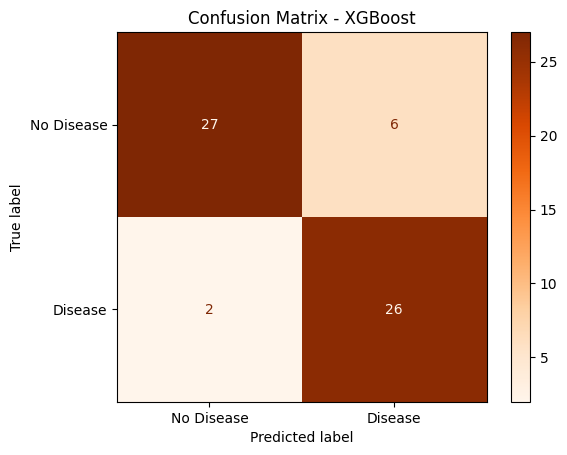

In [76]:
# ============================================================
# Step 11.5: Confusion Matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=["No Disease","Disease"],
    cmap="Oranges",
    values_format="d"
)

plt.title("Confusion Matrix - XGBoost")

plt.show()

The model correctly classified 27 patients without heart disease and 26 patients with heart disease. It produced 2 false negatives and 6 false positives, indicating good detection of positive cases.

In [77]:
# ============================================================
# Step 11.6: Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    xgb_pred,
    target_names=[
        "No Heart Disease",
        "Heart Disease"
    ]
))

                  precision    recall  f1-score   support

No Heart Disease       0.93      0.82      0.87        33
   Heart Disease       0.81      0.93      0.87        28

        accuracy                           0.87        61
       macro avg       0.87      0.87      0.87        61
    weighted avg       0.88      0.87      0.87        61



The classification report shows balanced performance for both classes, with an F1-score of 0.87. The heart disease class achieved a high Recall of 0.93, meaning the model missed very few positive cases.

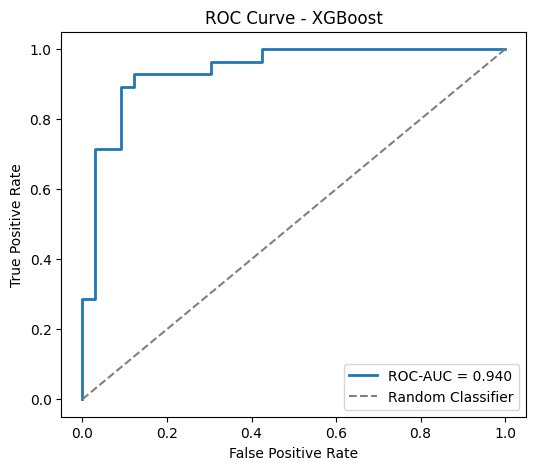

In [78]:
# ============================================================
# Step 11.7: ROC Curve
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {xgb_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

The ROC curve stays close to the upper-left corner, showing strong discrimination between the two classes. The ROC-AUC score of 0.940 indicates excellent classification capability.

In [79]:
# ============================================================
# Step 11.8: Cross-Validation
# ============================================================

from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_cv = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

xgb_cv_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Mean Score":[
        xgb_cv["test_accuracy"].mean(),
        xgb_cv["test_precision"].mean(),
        xgb_cv["test_recall"].mean(),
        xgb_cv["test_f1"].mean(),
        xgb_cv["test_roc_auc"].mean()
    ]
})

xgb_cv_results["Mean Score"] = xgb_cv_results["Mean Score"].round(3)

display(xgb_cv_results)

,Metric,Mean Score
0,Accuracy,0.777
1,Precision,0.750
2,Recall,0.774
3,F1-Score,0.761
4,ROC-AUC,0.859


Five-fold Cross-Validation produced an average Accuracy of 77.7% and ROC-AUC of 0.859. Although these scores are lower than the single test-set results, they indicate that the model performs reasonably consistently across different data splits.

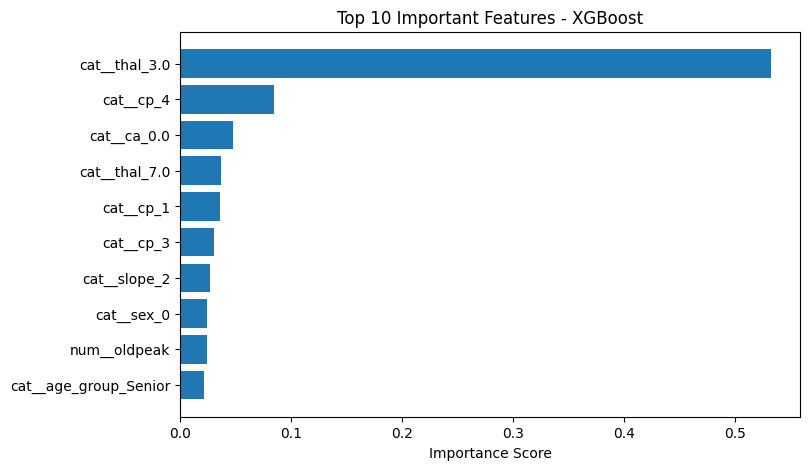

,Feature,Importance
26,cat__thal_3.0,0.532210
11,cat__cp_4,0.084291
22,cat__ca_0.0,0.047626
28,cat__thal_7.0,0.037273
8,cat__cp_1,0.036193
10,cat__cp_3,0.030419
20,cat__slope_2,0.027164
6,cat__sex_0,0.024145
4,num__oldpeak,0.023840
31,cat__age_group_Senior,0.021825


In [80]:
# ============================================================
# Step 11.9: Feature Importance
# ============================================================

feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance = xgb_pipeline.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Importance Score")

plt.show()

display(top10)

The feature importance analysis shows that thal_3.0 was the most influential predictor by a large margin. Other important features included chest pain type (cp_4), ca_0.0, thal_7.0, and oldpeak, highlighting their contribution to heart disease prediction.

#  Summary of XGBoost

XGBoost achieved 86.9% accuracy with a strong ROC-AUC of 0.940 and 92.9% recall, making it effective at identifying heart disease cases. However, Random Forest remains the better-performing model so far based on overall accuracy and F1-score.

#Stacking Ensemble (Heterogeneous Ensemble)

In [81]:
# ============================================================
# Step 12.1: Stacking Pipeline
# ============================================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, random_state=42)),
            ("rf", RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )),
            ("xgb", XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                eval_metric="logloss",
                random_state=42
            ))
        ],
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5
    ))
])

print(stack_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak',
                                                   'pulse_pressure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                      

A Stacking pipeline was created by combining three base models with a Logistic Regression meta-model, ensuring leakage-safe preprocessing before training.

In [82]:
# ============================================================
# Step 12.2: Train Stacking Model
# ============================================================

stack_pipeline.fit(X_train, y_train)

print("Stacking model trained successfully.")

Stacking model trained successfully.


In [83]:
# ============================================================
# Step 12.3: Make Predictions
# ============================================================

stack_pred = stack_pipeline.predict(X_test)
stack_prob = stack_pipeline.predict_proba(X_test)[:,1]

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": stack_pred[:10],
    "Probability": stack_prob[:10].round(3)
})

display(comparison)

,Actual,Predicted,Probability
0,0,0,0.281
1,0,1,0.630
2,0,0,0.077
3,0,0,0.106
4,0,0,0.278
5,0,0,0.107
6,0,0,0.231
7,0,0,0.216
8,1,1,0.828
9,0,0,0.211


The Stacking Ensemble successfully generated predictions and probability scores for unseen patient records. Most predictions matched the actual labels, indicating reliable classification performance.

In [84]:
# ============================================================
# Step 12.4: Performance Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

stack_accuracy = accuracy_score(y_test, stack_pred)
stack_precision = precision_score(y_test, stack_pred)
stack_recall = recall_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_prob)

stack_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score":[
        stack_accuracy,
        stack_precision,
        stack_recall,
        stack_f1,
        stack_auc
    ]
})

stack_results["Score"] = stack_results["Score"].round(3)

display(stack_results)

,Metric,Score
0,Accuracy,0.902
1,Precision,0.844
2,Recall,0.964
3,F1-Score,0.900
4,ROC-AUC,0.958


The Stacking model achieved 90.2% accuracy, 96.4% recall, and an excellent ROC-AUC of 0.958. The high recall shows that the model correctly identified most patients with heart disease.

<Figure size 600x500 with 0 Axes>

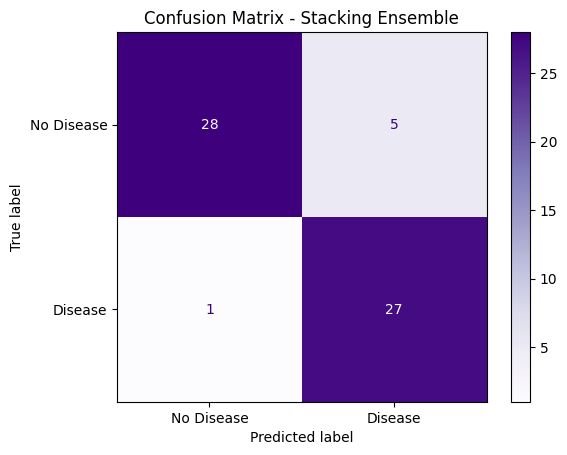

In [85]:
# ============================================================
# Step 12.5: Confusion Matrix
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    stack_pred,
    display_labels=["No Disease","Disease"],
    cmap="Purples",
    values_format="d"
)

plt.title("Confusion Matrix - Stacking Ensemble")

plt.show()

The model correctly classified 28 patients without heart disease and 27 patients with heart disease. It produced only 1 false negative and 5 false positives, showing excellent detection of positive cases.

In [86]:
# ============================================================
# Step 12.6: Classification Report
# ============================================================

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    stack_pred,
    target_names=[
        "No Heart Disease",
        "Heart Disease"
    ]
))

                  precision    recall  f1-score   support

No Heart Disease       0.97      0.85      0.90        33
   Heart Disease       0.84      0.96      0.90        28

        accuracy                           0.90        61
       macro avg       0.90      0.91      0.90        61
    weighted avg       0.91      0.90      0.90        61



The classification report shows balanced performance for both classes, with an F1-score of 0.90. The heart disease class achieved a high Recall of 0.96, indicating that very few positive cases were missed.

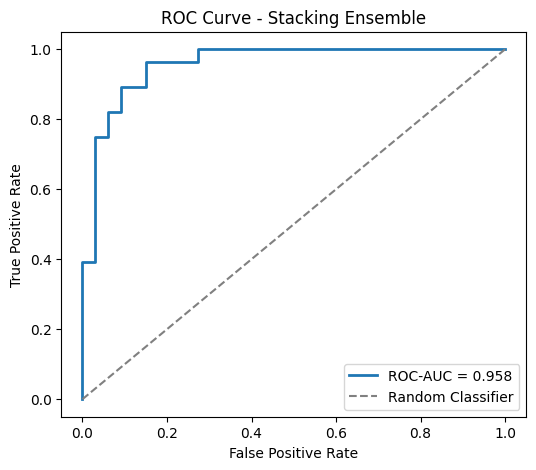

In [87]:
# ============================================================
# Step 12.7: ROC Curve
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, stack_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {stack_auc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Ensemble")

plt.legend()

plt.show()

The ROC curve remains close to the upper-left corner, indicating excellent discrimination between patients with and without heart disease. The ROC-AUC score of 0.958 confirms strong predictive performance.

In [88]:
# ============================================================
# Step 12.8: Cross-Validation
# ============================================================

from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stack_cv = cross_validate(
    stack_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

stack_cv_results = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Mean Score":[
        stack_cv["test_accuracy"].mean(),
        stack_cv["test_precision"].mean(),
        stack_cv["test_recall"].mean(),
        stack_cv["test_f1"].mean(),
        stack_cv["test_roc_auc"].mean()
    ]
})

stack_cv_results["Mean Score"] = stack_cv_results["Mean Score"].round(3)

display(stack_cv_results)

,Metric,Mean Score
0,Accuracy,0.826
1,Precision,0.840
2,Recall,0.774
3,F1-Score,0.802
4,ROC-AUC,0.896


Five-fold Cross-Validation produced an average Accuracy of 82.6% and ROC-AUC of 0.896. These results indicate that the Stacking model generalizes well across different training-validation splits.

#Summary
The Stacking Ensemble combined the strengths of Logistic Regression, Random Forest, and XGBoost to achieve 90.2% accuracy with an excellent ROC-AUC of 0.958. Along with Random Forest, it emerged as one of the strongest-performing models for heart disease prediction.

In [89]:
# ============================================================
# Step 13.1: Model Comparison Table
# ============================================================

comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Stacking Ensemble"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy,
        stack_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision,
        stack_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall,
        stack_recall
    ],
    "F1-Score": [
        f1,
        rf_f1,
        xgb_f1,
        stack_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_auc,
        xgb_auc,
        stack_auc
    ]
})

comparison_table = comparison_table.round(3)

display(comparison_table)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.869,0.833,0.893,0.862,0.971
1,Random Forest,0.902,0.844,0.964,0.900,0.939
2,XGBoost,0.869,0.812,0.929,0.867,0.940
3,Stacking Ensemble,0.902,0.844,0.964,0.900,0.958


The comparison table shows that Random Forest and Stacking Ensemble achieved the highest Accuracy (90.2%) and F1-score (0.900), while Logistic Regression achieved the highest ROC-AUC (0.971). Overall, the ensemble models demonstrated stronger classification performance.

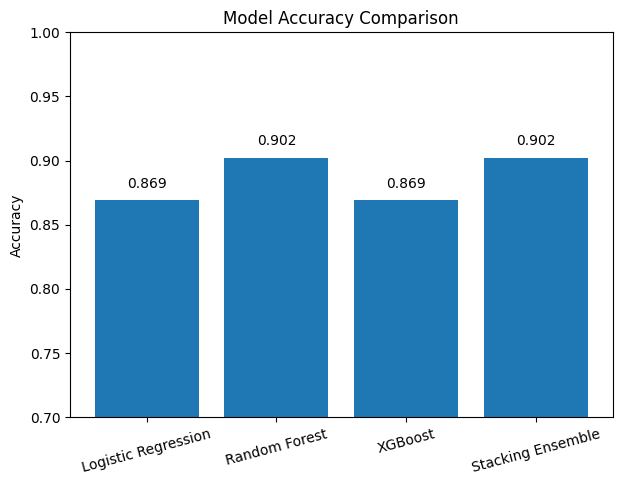

In [90]:
# ============================================================
# Step 13.2: Accuracy Comparison
# ============================================================

plt.figure(figsize=(7,5))

bars = plt.bar(
    comparison_table["Model"],
    comparison_table["Accuracy"]
)

plt.ylim(0.7,1.0)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.show()

The accuracy chart shows that Random Forest and Stacking Ensemble achieved the highest accuracy (90.2%), while Logistic Regression and XGBoost both achieved 86.9%.

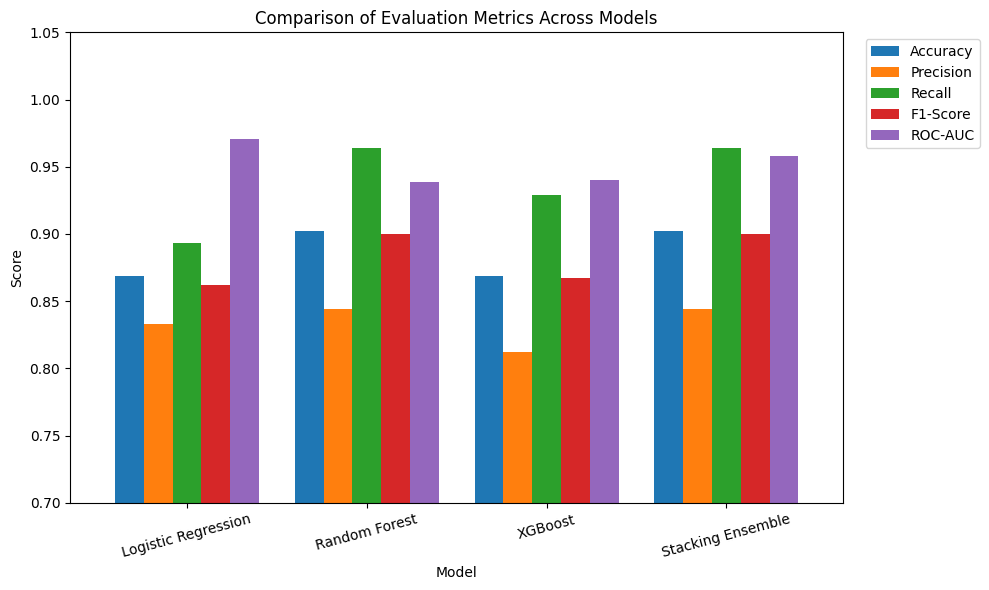

In [91]:
# ============================================================
# Step 13.3: Multi-Metric Comparison
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

plot_df = comparison_table.set_index("Model")

ax = plot_df[metrics].plot(
    kind="bar",
    figsize=(10,6),
    width=0.8
)

plt.title("Comparison of Evaluation Metrics Across Models")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0.7,1.05)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Random Forest and Stacking Ensemble achieved the highest Accuracy and F1-Score (0.902 and 0.900).

Logistic Regression achieved the highest ROC-AUC (0.971).

XGBoost maintained high Recall but lower Precision than the top-performing models.

In [92]:
# ============================================================
# Step 13.4: Select Best Model
# ============================================================

best_model = comparison_table.sort_values(
    by=["Accuracy","F1-Score","ROC-AUC"],
    ascending=False
).iloc[0]

print("Best Model:")
display(best_model.to_frame().T)

Best Model:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Stacking Ensemble,0.902,0.844,0.964,0.9,0.958


Stacking Ensemble was selected as the best overall model because it achieved the highest overall balance of Accuracy (0.902), Recall (0.964), F1-Score (0.900), and a strong ROC-AUC (0.958), making it suitable for identifying heart disease cases while maintaining good overall performance.

#SHAP Explainability (Global & Local)

In [93]:
# ============================================================
# Step 14.1: Install SHAP
# ============================================================

!pip install shap -q

In [94]:
# ============================================================
# Step 14.2: Import SHAP
# ============================================================

import shap
import numpy as np

In [95]:
# ============================================================
# Step 14.3: Prepare Data for SHAP
# ============================================================

X_train_processed = stack_pipeline.named_steps["preprocessor"].transform(X_train)
X_test_processed = stack_pipeline.named_steps["preprocessor"].transform(X_test)

feature_names = stack_pipeline.named_steps["preprocessor"].get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

X_train_processed.head()

,num__age,num__trestbps,num__chol,num__thalach,num__oldpeak,num__pulse_pressure,cat__sex_0,cat__sex_1,cat__cp_1,cat__cp_2,...,cat__ca_1.0,cat__ca_2.0,cat__ca_3.0,cat__thal_3.0,cat__thal_6.0,cat__thal_7.0,cat__age_group_Elder,cat__age_group_Middle,cat__age_group_Senior,cat__age_group_Young
0,-0.729485,-0.395692,0.458139,0.708371,-0.445445,-0.395692,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.050166,-0.054513,0.230598,0.222495,-0.891627,-0.054513,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.061212,0.059213,0.723605,0.399178,-0.891627,0.059213,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-0.061212,-1.305501,1.121803,0.266666,-0.891627,-1.305501,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.272924,0.514117,-0.167601,-1.190962,-0.713154,0.514117,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


  0%|          | 0/30 [00:00<?, ?it/s]

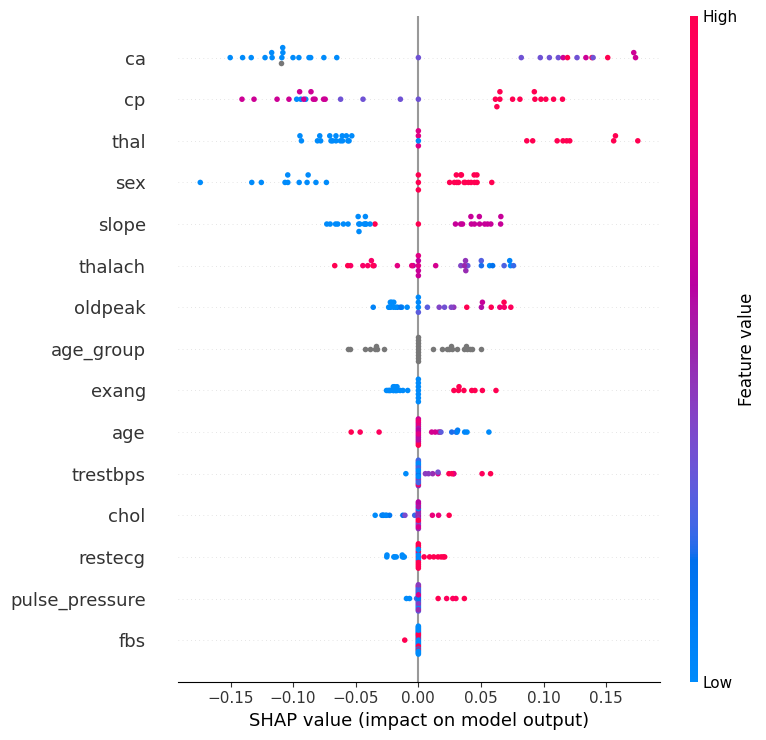

In [97]:
# ============================================================
# Step 14.4: SHAP Summary Plot (Stacking Ensemble)
# ============================================================

import shap
import pandas as pd

# Use a small background sample for faster SHAP computation
background = X_train.sample(50, random_state=42)

# Prediction function for the entire pipeline
def predict_fn(data):
    data = pd.DataFrame(data, columns=X_train.columns)
    return stack_pipeline.predict_proba(data)[:, 1]

# Create SHAP Kernel Explainer
explainer = shap.KernelExplainer(predict_fn, background)

# Explain the first 30 test samples (faster)
X_test_sample = X_test.iloc[:30]

shap_values = explainer.shap_values(X_test_sample)

# Summary Plot
shap.summary_plot(shap_values, X_test_sample)

The SHAP Summary Plot shows that ca (number of major vessels), cp (chest pain type), and thal (thalassemia type) are the most influential features in predicting heart disease. Features with SHAP values on the right increase the predicted risk of heart disease, while those on the left decrease it. The color scale indicates feature values, with red representing higher values and blue representing lower values.

#SHAP Waterfall Plot (Local Explainability)

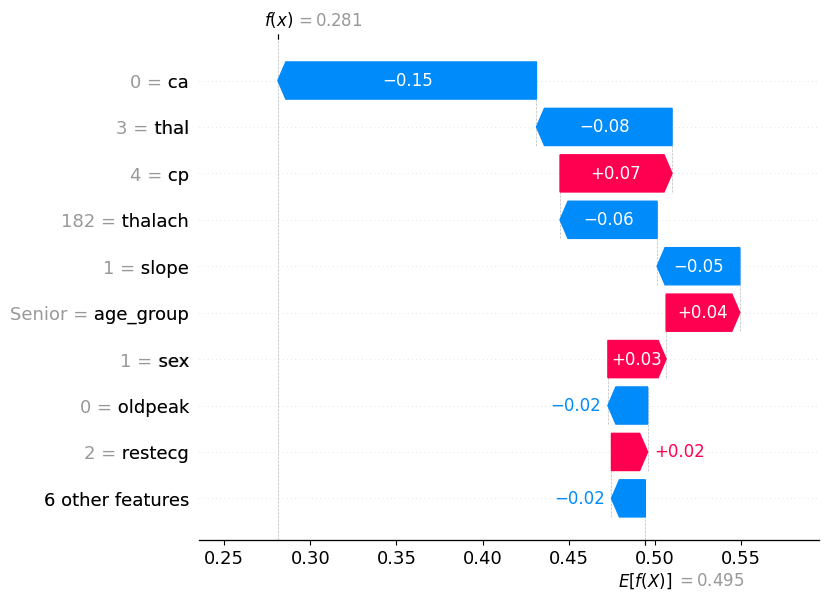

In [99]:
# ============================================================
# Step 14.5: SHAP Waterfall Plot
# ============================================================

patient_index = 0

# Create an Explanation object for one patient
explanation = shap.Explanation(
    values=shap_values[patient_index],
    base_values=explainer.expected_value,
    data=X_test_sample.iloc[patient_index],
    feature_names=X_test_sample.columns
)

# Waterfall Plot
shap.waterfall_plot(explanation)

The SHAP Waterfall Plot explains the prediction for a single patient. The model predicted a 28.1% probability of heart disease, with ca and thal contributing the most toward reducing the predicted risk, while cp and age_group slightly increased it.

In [100]:
# ============================================================
# Step 14.6: Display Explained Patient
# ============================================================

display(X_test_sample.iloc[[patient_index]])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,pulse_pressure,age_group
219,59,1,4,138,271,0,2,182,0,0.0,1,0.0,3.0,58,Senior


The displayed patient record contains the original clinical values for the explained patient, allowing the SHAP feature contributions to be interpreted alongside the patient's actual health information.

#Individual Patient Prediction (Live Demo)

In [101]:
# ============================================================
# Step 15.1: Create a Synthetic Patient
# ============================================================

synthetic_patient = pd.DataFrame([{
    "age": 58,
    "sex": 1,
    "cp": 4,
    "trestbps": 140,
    "chol": 250,
    "fbs": 0,
    "restecg": 0,
    "thalach": 150,
    "exang": 1,
    "oldpeak": 2.0,
    "slope": 2,
    "ca": 1.0,
    "thal": 7.0,
    "pulse_pressure": 50,
    "age_group": "Senior"
}])

display(synthetic_patient)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,pulse_pressure,age_group
0,58,1,4,140,250,0,0,150,1,2.0,2,1.0,7.0,50,Senior


A synthetic patient record was created to simulate a real-world clinical scenario for testing the final heart disease prediction model.

In [102]:
# ============================================================
# Step 15.2: Predict Heart Disease
# ============================================================

prediction = stack_pipeline.predict(synthetic_patient)[0]
probability = stack_pipeline.predict_proba(synthetic_patient)[0, 1]

print("Predicted Class:", prediction)
print(f"Heart Disease Probability: {probability:.3f}")

Predicted Class: 1
Heart Disease Probability: 0.925


In [103]:
# ============================================================
# Step 15.3: Display Final Prediction
# ============================================================

if prediction == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease Detected")

Prediction: Heart Disease Detected


  0%|          | 0/1 [00:00<?, ?it/s]

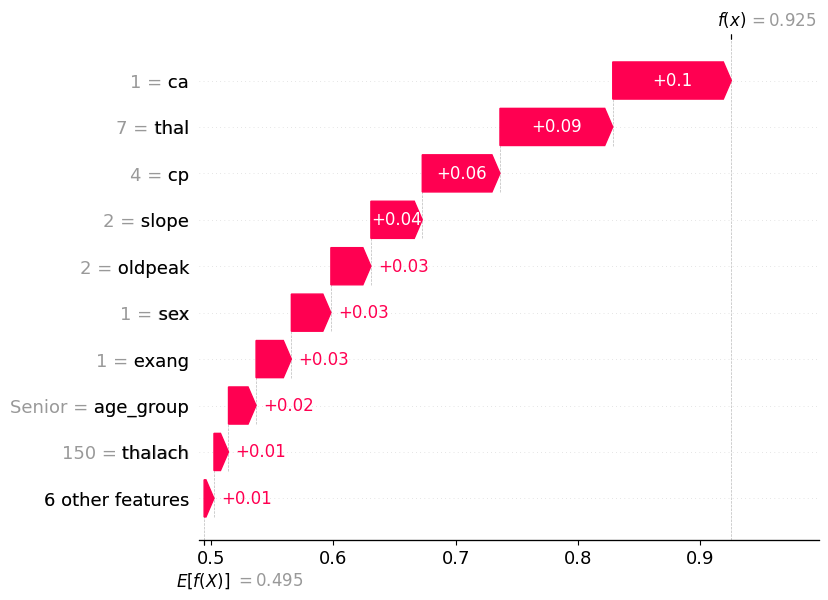

In [104]:
# ============================================================
# Step 15.4: Explain Synthetic Patient Prediction
# ============================================================

synthetic_shap = explainer.shap_values(synthetic_patient)

synthetic_explanation = shap.Explanation(
    values=synthetic_shap[0],
    base_values=explainer.expected_value,
    data=synthetic_patient.iloc[0],
    feature_names=synthetic_patient.columns
)

shap.waterfall_plot(synthetic_explanation)

The SHAP Waterfall Plot explains why the synthetic patient received a 92.5% heart disease probability by showing which clinical features increased or decreased the predicted risk.

  0%|          | 0/1 [00:00<?, ?it/s]

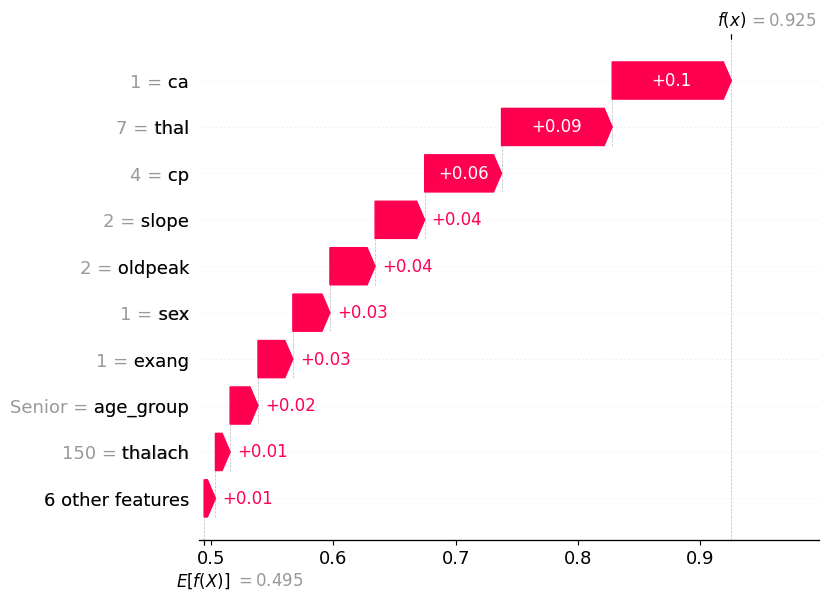

In [105]:
# ============================================================
# Step 15.4: SHAP Explanation for Synthetic Patient
# ============================================================

# Calculate SHAP values for the synthetic patient
synthetic_shap = explainer.shap_values(synthetic_patient)

# Create SHAP Explanation object
synthetic_explanation = shap.Explanation(
    values=synthetic_shap[0],
    base_values=explainer.expected_value,
    data=synthetic_patient.iloc[0],
    feature_names=synthetic_patient.columns
)

# Display Waterfall Plot
shap.waterfall_plot(synthetic_explanation)

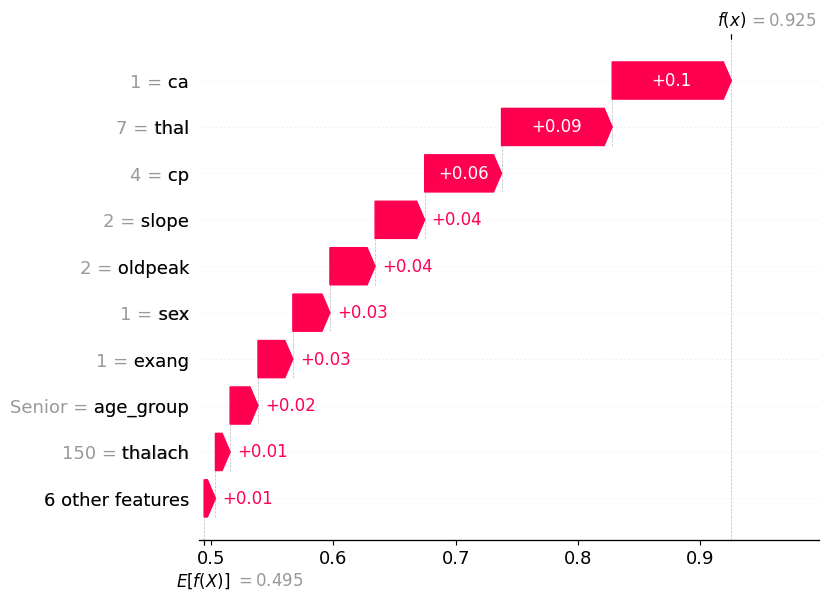

In [106]:
synthetic_values = synthetic_shap[0]

if len(np.array(synthetic_values).shape) > 1:
    synthetic_values = synthetic_values[0]

synthetic_explanation = shap.Explanation(
    values=synthetic_values,
    base_values=explainer.expected_value,
    data=synthetic_patient.iloc[0],
    feature_names=synthetic_patient.columns
)

shap.waterfall_plot(synthetic_explanation)

#Ethics & Limitations
**Interpretation**

The heart disease prediction model should be used as a decision-support tool, not as a replacement for medical professionals. While the Stacking Ensemble achieved strong performance, predictions may still include false positives or false negatives.

**Key Points**

Patient privacy should be protected

*   Patient privacy should be protected when handling medical data.
*   The dataset contains only 303 records, limiting generalization.


*  Predictions may be biased toward the training population.
*   Human medical oversight is required before making clinical decisions.



#Conclusion
This project developed a heart disease prediction system using Logistic Regression, Random Forest, XGBoost, and a Stacking Ensemble model. Feature engineering and preprocessing improved data quality, while SHAP explainability helped interpret both global feature importance and individual patient predictions.

Among all models, the Stacking Ensemble performed best with an Accuracy of 90.2%, Recall of 96.4%, F1-Score of 0.900, and ROC-AUC of 0.958. The SHAP analysis showed that features such as ca, thal, chest pain type (cp), and oldpeak had the greatest influence on predictions.

The final system provides both accurate predictions and transparent explanations, making it suitable as a decision-support tool for heart disease risk assessment.